# **005 Step 1~4 Framework Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

### ***Reading a file***

In [2]:
pd.read_excel("data/bluebook-for-bulldozers/Data Dictionary.xlsx")

C:\Users\HP\Desktop\ml-course-following\bulldozer-price-prediction-project\env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Variable,Description,Unnamed: 2
0,SalesID,unique identifier of a particular sale of a ...,NaN
1,MachineID,identifier for a particular machine; machin...,NaN
2,ModelID,identifier for a unique machine model (i.e. ...,NaN
3,datasource,source of the sale record; some sources are...,NaN
4,auctioneerID,"identifier of a particular auctioneer, i.e. ...",NaN
5,YearMade,year of manufacturer of the Machine,NaN
6,MachineHoursCurrentMeter,current usage of the machine in hours at tim...,NaN
7,UsageBand,"value (low, medium, high) calculated compari...",NaN
8,Saledate,time of sale,NaN
9,Saleprice,cost of sale in USD,NaN


# **006 Exploring Our Data**

### **Importing TrainAndValid.csv**

In [3]:
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False)
# We used low_memory=False bcos of the warning given to us when we dont have low_memory=False

### **Getting info on df**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   str    
 14 

### **Checking for missing values in dataset**

In [5]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

### **Let's plot**
***Since we're trying to predict sale price and we know that our data is a time series, it's good to plot. What we might want to look at is smth like comparing sale dates with sale price***

***Now since the data is much, it might pose an issue for our computer to draw scattered dots, so we might just take 1000 samples to draw the plot***

In [6]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='str')

## **ChatGpt helping me to know what to plot:**
***Since u're working with the Buldozer Sales dataset and trying to predict `SalePrice`, there are several useful things u can plot.***

***The main idea is to look for relationships btw features and `SalePrice` i.e what affects `SalePrice`***

### **1. Sale date vs Sale price:**


***We parse the below bcos we want pandas to treat `saledate` column as actual  dates instead of plain test(i.e string)***

In [7]:
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv",
                low_memory=False,
                parse_dates=["saledate"]
                )
df["saledate"][:1000]

0     2006-11-16
1     2004-03-26
2     2004-02-26
3     2011-05-19
4     2009-07-23
         ...    
995   2009-07-16
996   2007-06-14
997   2005-09-22
998   2005-07-28
999   2011-06-16
Name: saledate, Length: 1000, dtype: datetime64[us]

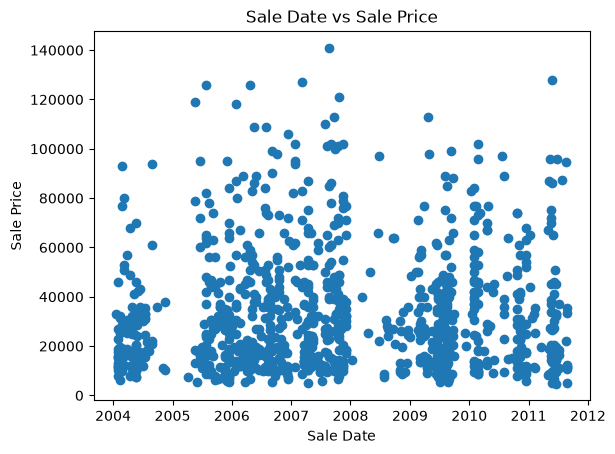

In [8]:
# Remeber we use plt.show() or a ';' after the last code
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000]);

ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price")
ax.set_title("Sale Date vs Sale Price");

### **2. Machine Year vs Sale Price**

**This is checking:**

> ***Do newer bulldozers generally sell for more?***

***You may notice that newer machines tend to have higher prices, although there will probably be a lot of variation.***

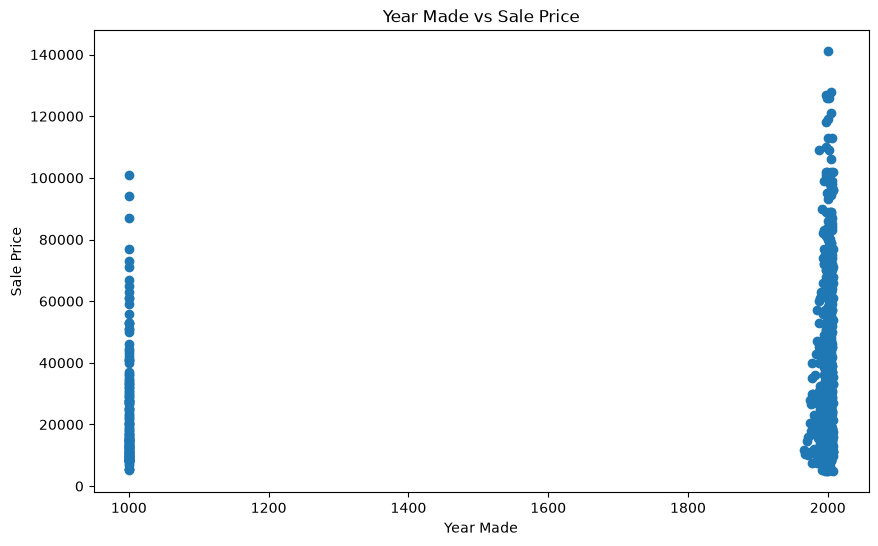

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df["YearMade"][:1000], df["SalePrice"][:1000])

ax.set_xlabel("Year Made")
ax.set_ylabel("Sale Price")
ax.set_title("Year Made vs Sale Price")

plt.show()

***Now the irregular plot above shows that around `1000 and 2000` on the YearMade axis, that bulldozers obviously weren't manufactured in years `1000 and 2000`***

***The `YearMade` column contains bad/special values, particularly `1000`.***

***In the Bulldozer dataset, 1000 is essentially being used as a placeholder for unknown/missing year information. Hence the type of graph we have above***

### **Let's check it by doing the below:**
***We will probably see `1000` in the YearMade***

In [10]:
df["YearMade"].value_counts().head(20)

YearMade
1000    39391
2005    22096
1998    21751
2004    20914
1999    19274
1997    19269
2000    17238
1996    17001
1995    15806
2003    14661
1994    14471
2006    13426
2001    13385
2002    12473
1993    11181
1989    10785
1988    10546
1990    10379
1987    10191
1992     7711
Name: count, dtype: int64

In [11]:
df["YearMade"].min()

np.int64(1000)

#### **Why is this useful?**

***This is exactly why we explore the dataset before modelling.***

***You have discovered that:***

> ***YearMade contains an invalid/placeholder value of 1000.***

***Later, when we're cleaning the data, we'll need to decide how to handle those values.***

***For now, don't delete or replace them just because the plot looks strange. You're still in the exploration stage.***

***You can make a cleaner exploratory plot by temporarily excluding the 1000 values:***

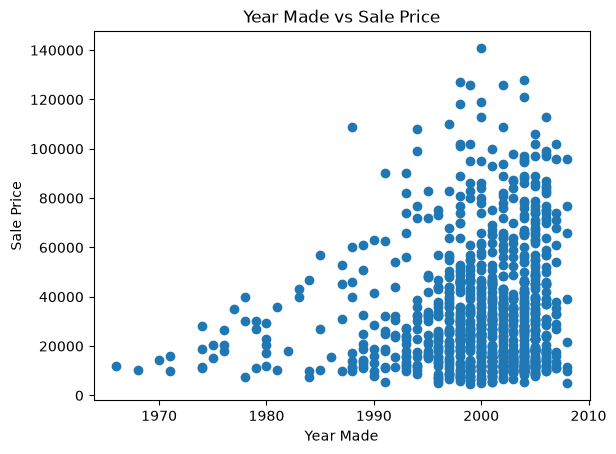

In [12]:
year_price = df[df["YearMade"] != 1000]

fig, ax = plt.subplots()
ax.scatter(
    year_price["YearMade"][:1000],
    year_price["SalePrice"][:1000]
)

ax.set_xlabel("Year Made")
ax.set_ylabel("Sale Price")
ax.set_title("Year Made vs Sale Price");

### **3. Machine Hours vs Sale Price**

**Look for columns related to usage.**

**This checks:**

> ***Does a machine with more hours tend to sell for less?***

***This is similar to mileage on a car.***

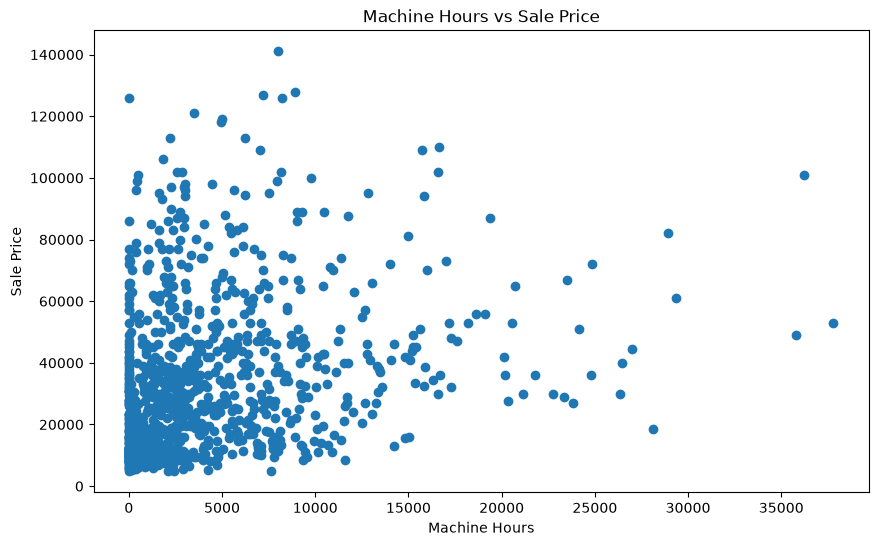

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["MachineHoursCurrentMeter"][:1000],
    df["SalePrice"][:1000]
)

ax.set_xlabel("Machine Hours")
ax.set_ylabel("Sale Price")
ax.set_title("Machine Hours vs Sale Price");

### **4. Year Made vs Machine Hours**

***This isn't directly about price, but it helps you understand the machines.***

**You're asking:**

> ***Are older machines generally more heavily used?***

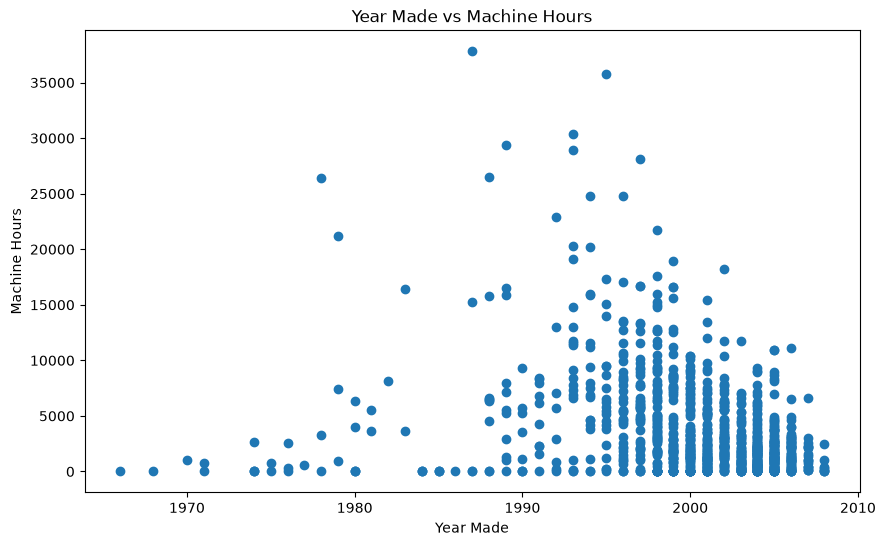

In [14]:
# First removing the year = 1000, so we do not get an irregular plot
year_price = df[df["YearMade"] != 1000]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    year_price["YearMade"][:1000],
    year_price["MachineHoursCurrentMeter"][:1000]
)

ax.set_xlabel("Year Made")
ax.set_ylabel("Machine Hours")
ax.set_title("Year Made vs Machine Hours");

### **5. Product Size vs Sale Price**

***There is a ProductSize column.***

**a) First, inspect it:**

In [15]:
df["ProductSize"].value_counts()

ProductSize
Medium            64342
Large / Medium    51297
Small             27057
Mini              25721
Large             21396
Compact            6280
Name: count, dtype: int64

**b) Then you can compare the average price:**

**This is very useful because you might discover something like:**

> ***Larger machines generally have higher sale prices.***

**c) Then calculate the average sale price for each size:**

In [16]:
df.groupby("ProductSize")["SalePrice"].mean().sort_values()

ProductSize
Mini              15194.647720
Compact           17498.578822
Small             32511.164061
Large             42023.433315
Medium            45703.873473
Large / Medium    47828.923231
Name: SalePrice, dtype: float64

**d) Then plot them:**

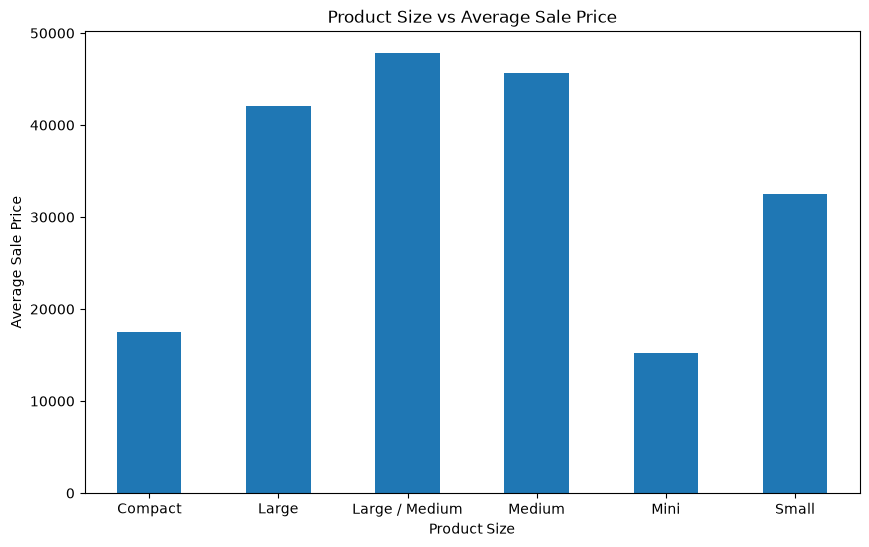

In [17]:
df.groupby("ProductSize")["SalePrice"].mean().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Product Size")
plt.ylabel("Average Sale Price")
plt.title("Product Size vs Average Sale Price")
plt.xticks(rotation=0);

### **6. Enclosure vs Sale Price**

**There is an Enclosure column.**

***a) Check:***

In [18]:
df["Enclosure"].value_counts()

Enclosure
OROPS                  177971
EROPS                  141769
EROPS w AC              92601
EROPS AC                   18
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64

***b) Then do the below: This helps you see whether different enclosure types are associated with different prices.***


In [19]:
df.groupby("Enclosure")["SalePrice"].mean().sort_values()

Enclosure
None or Unspecified    16500.000000
OROPS                  22592.082739
EROPS AC               23500.000000
EROPS                  28687.993278
NO ROPS                44333.333333
EROPS w AC             51671.169728
Name: SalePrice, dtype: float64

**c) Then Plot:**

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'EROPS'),
  Text(1, 0, 'EROPS AC'),
  Text(2, 0, 'EROPS w AC'),
  Text(3, 0, 'NO ROPS'),
  Text(4, 0, 'None or Unspecified'),
  Text(5, 0, 'OROPS')])

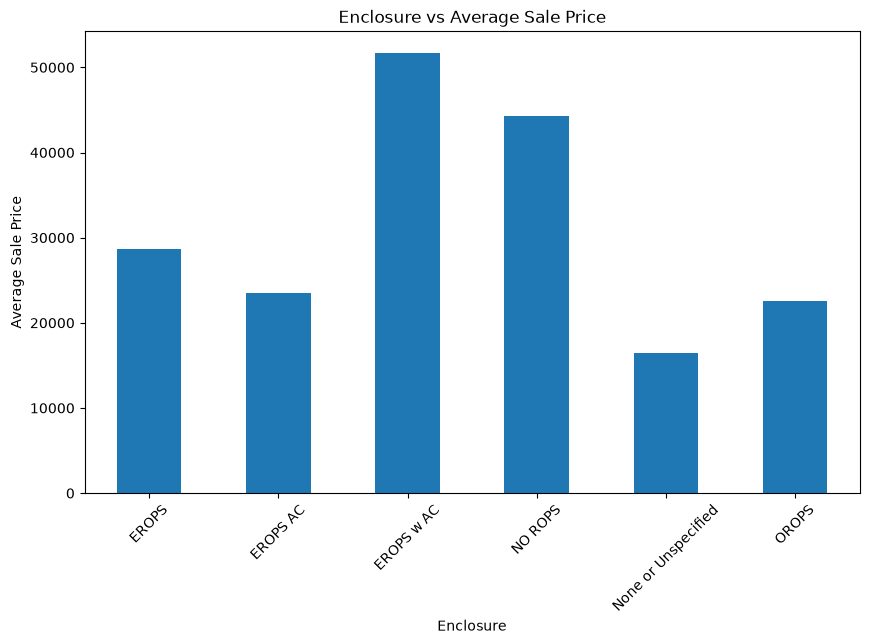

In [20]:
df.groupby("Enclosure")["SalePrice"].mean().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Enclosure")
plt.ylabel("Average Sale Price")
plt.title("Enclosure vs Average Sale Price")
plt.xticks(rotation=45)

### **7. Transmission vs Sale Price**

**You can do the same thing with Transmission:**

**a)Check:**

In [21]:
df["Transmission"].value_counts()

Transmission
Standard               143915
None or Unspecified     23889
Powershift              11991
Powershuttle             4286
Hydrostatic              3342
Direct Drive              422
Autoshift                 118
AutoShift                  44
Name: count, dtype: int64

**b)Then find the mean:**

In [22]:
df.groupby("Transmission")["SalePrice"].mean().sort_values()

Transmission
Direct Drive            18675.829384
Powershuttle            19264.930938
Standard                28364.132218
Autoshift               33141.949153
Hydrostatic             34705.814183
Powershift              38574.352931
None or Unspecified     47354.812968
AutoShift              102261.363636
Name: SalePrice, dtype: float64

**c) Then Plot:**

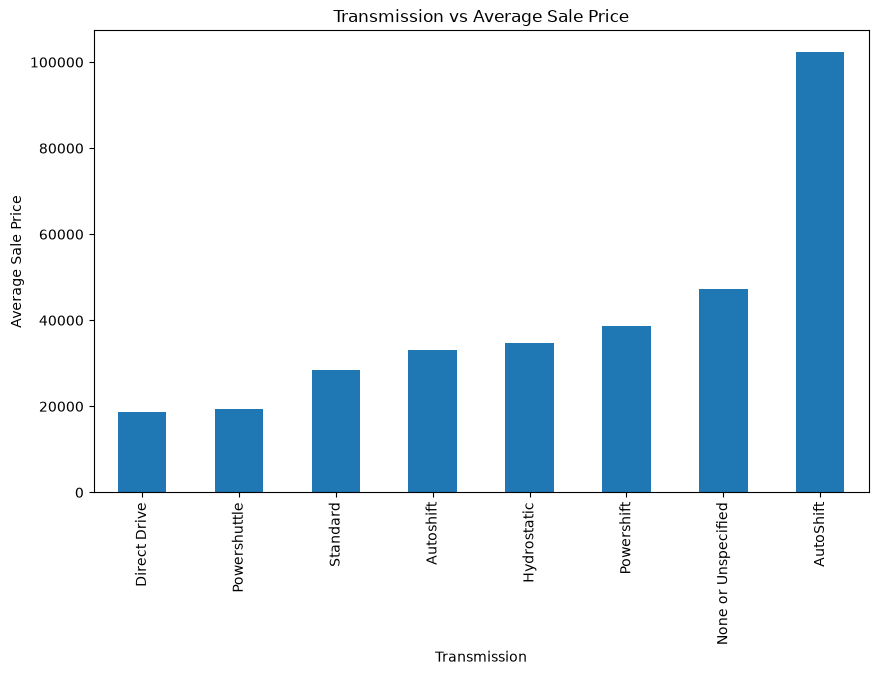

In [23]:
df.groupby("Transmission")["SalePrice"].mean().sort_values().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Transmission")
plt.ylabel("Average Sale Price")
plt.title("Transmission vs Average Sale Price");

### **8. Model ID vs Sale Price**

**This can be particularly interesting:**

**This tells you:**

> ***Which machine models have historically sold for the highest average prices?***

***However, there are thousands of ModelIDs, so don't try to make a huge plot of all of them.***

**a) First, let's see how many different model IDs there are:**

In [24]:
df["ModelID"].nunique()

5281

**b) Then check which model IDs appear most often:**

In [25]:
df["ModelID"].value_counts().head(20)

ModelID
4605    5348
3538    4976
3170    4364
4604    4296
3362    4186
3537    3748
3171    3481
4603    3443
3357    3270
3178    3173
9550    2883
3112    2672
3542    2550
3854    2508
4579    2504
4147    2457
6788    2394
7277    2305
9551    2102
4146    2033
Name: count, dtype: int64

**c) To see the average SalePrice for each ModelID:**

In [26]:
df.groupby("ModelID")["SalePrice"].mean().sort_values(ascending=False).head(20)

ModelID
3352     136000.000000
18226    135000.000000
18228    131400.000000
14443    128200.000000
24276    125000.000000
16364    124000.000000
22714    120000.000000
3372     118865.384615
1660     115833.333333
22019    114285.714286
30567    114045.454545
18223    113733.333333
14427    112520.833333
14406    111978.723404
1630     111275.000000
2771     110662.162162
3375     110428.571429
28028    110000.000000
25555    109000.000000
11937    108750.000000
Name: SalePrice, dtype: float64

**d) But should we make a bar chart?**
> ***Not for all Model IDs. There are likely hundreds or thousands of different models, so a bar chart would become unreadable.***

***Instead, we can look at the most common models and compare their average prices:***

In [27]:
model_counts = df["ModelID"].value_counts().head(10)

model_counts

ModelID
4605    5348
3538    4976
3170    4364
4604    4296
3362    4186
3537    3748
3171    3481
4603    3443
3357    3270
3178    3173
Name: count, dtype: int64

**Then we do:**

**This part in the code `df[df["ModelID"].isin(model_counts.index)]` filters the DataFrame and keeps only the rows whose ModelID is in model_counts.index**

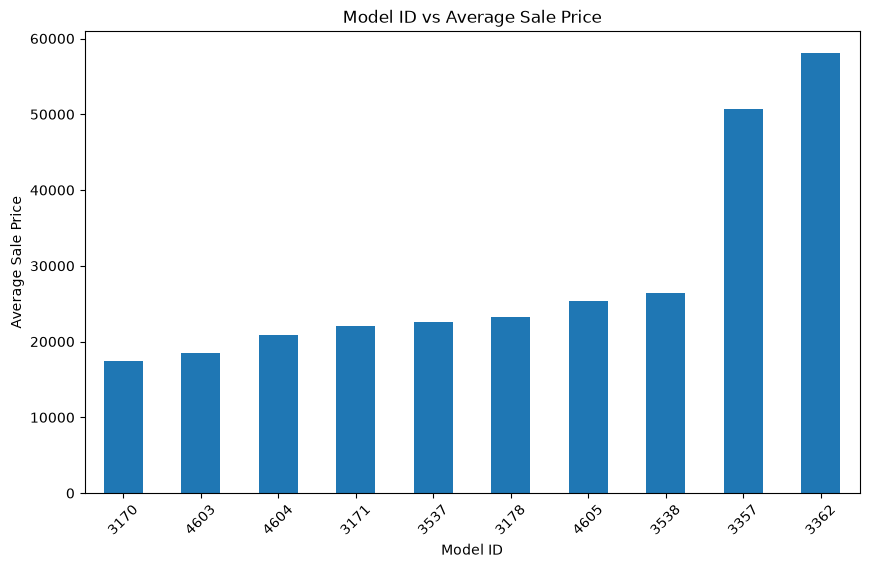

In [28]:
df[df["ModelID"].isin(model_counts.index)].groupby("ModelID")["SalePrice"].mean().sort_values().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Model ID")
plt.ylabel("Average Sale Price")
plt.title("Model ID vs Average Sale Price")
plt.xticks(rotation=45)
plt.show()

### **9. Check the distribution of SalePrice itself**

**This is one I definitely recommend.**

**You're trying to understand:**

> ***What does the target variable actually look like?***

***You may find that most bulldozers sell at relatively lower prices while a smaller number sell for very high prices.***

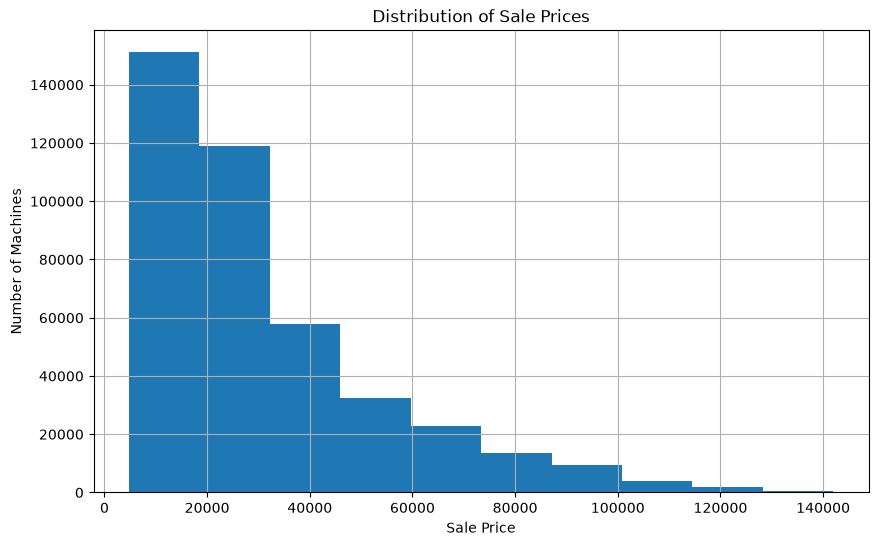

In [29]:
df["SalePrice"].hist(figsize=(10, 6))

plt.xlabel("Sale Price")
plt.ylabel("Number of Machines")
plt.title("Distribution of Sale Prices");

# **007 Exploring Our Data 2**

In [30]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [31]:
df["saledate"].head(20)

0    2006-11-16
1    2004-03-26
2    2004-02-26
3    2011-05-19
4    2009-07-23
5    2008-12-18
6    2004-08-26
7    2005-11-17
8    2009-08-27
9    2007-08-09
10   2008-08-21
11   2006-08-24
12   2005-10-20
13   2006-01-26
14   2006-01-03
15   2006-11-16
16   2007-06-14
17   2010-01-28
18   2006-03-09
19   2005-11-17
Name: saledate, dtype: datetime64[us]

### **Sort DataFrame by `saledate`**

#### ***This is especially important for time-series or time-based prediction problems, where we use data from the past to make predictions about future events. It is advisable to sort the data by date so that the observations are arranged chronologically. This helps us separate past data from future data correctly and reduces the risk of using future information to predict the past.***


In [32]:
df = df.sort_values(by=["saledate"], ascending=True)
df["saledate"].head(20)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
Name: saledate, dtype: datetime64[us]

### **Make copy of the Original dataframe**
***This is bcos even when we've manipulated the copy, we still get the original data***

In [33]:
df_tmp = df.copy()
df_tmp["saledate"].head(20)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
Name: saledate, dtype: datetime64[us]

#### **So we will work with the copied data i.e df_tmp**

# **008 Feature Engineering**

***So what we're going to do in this video is we're going to take these dates and use pandas date time, as well as sm pandas date time attribute to enrich our dataset. This is known as feature engineering as seen below:***

#### **Add date time parameters so we can access attribute of the date:**
***The reason for this is so u can know if it was in the start of a quarter that sales increased or not, or maybe it was in the end of a quarter that sales are going down bcos everyone's tight on budget etc. Also, so that we can access day, date, year, etc.***

In [34]:
df_tmp["saleYear"] = df_tmp.saledate.dt.year
df_tmp["saleMonth"] = df_tmp.saledate.dt.month
df_tmp["saleDay"] = df_tmp.saledate.dt.day
df_tmp["saleDayOfWeek"] = df_tmp.saledate.dt.dayofweek
df_tmp["saleDayOfYear"] = df_tmp.saledate.dt.dayofyear

In [35]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


#### **Remove the saleDate column**
***Since we have gotten the info we want from the saleDate column, we can just remove it***

In [36]:
df_tmp = df_tmp.drop("saledate", axis=1)

### **Check the values of sm columns**

In [37]:
df_tmp.state.value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Montana            1336
Iowa               1336
Oklahoma           1326
Nebraska            866
West Virgi

# **Modelling**

***We've done enough EDA(Exploratory data analysis), but let's start to do sm model-driven EDA***

#### **Let's build a ML model**
**To know the scikit learn models to use, we go to ur map: https://scikit-learn.org/stable/tutorial/machine_learning_map/index_html**


# **009 Turning Data Into Numbers**

**Checking for Missiing data**

In [38]:
df_tmp.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

In [39]:
df_tmp.info()

<class 'pandas.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   fiModelDesc               412698 non-null  str    
 10  fiBaseModel               412698 non-null  str    
 11  fiSecondaryDesc           271971 non-null  str    
 12  fiModelSeries             58667 non-null   str    
 13  fiModelDescriptor         74816 non-null   str    
 14 

### **Convert to Numeric**
***Convert strings to Categories : One way we can turn all of our data to numbers is by converting them to Pandas Categories***

***A machine-learning model cannot directly calculate with "Medium" or "Texas" the way it can with numbers such as 500, 2006, or 45000.***

**So what does "Convert strings to Categories" mean?**
> ***Pandas allows us to change a text column into a categorical column:***

**Why is this useful?**
>***Because eventually we need to get the dataset into a form like:***

***YearMade: 2006, 2008***

***ProductSize: 4, 5***

***state: 10, 15***

***SalePrice: 35000, 42000***

**instead of:**

***YearMade: 2006, 2008***

***ProductSize: Medium, Large***

***state: Alabama, Texas***

***SalePrice: 35000, 42000***

***We can check Pandas' documentation for information about different data types and functions used to work with them here:(https://pandas.pydata.org/pandas-docs/stable/reference/general_utility_functions.html?utm_source=chatgpt.com#data-types-related-functionality)***

In [40]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


#### ***Just checking a random Column if its a string***

In [41]:
pd.api.types.is_string_dtype(df_tmp["UsageBand"]) 

True

### **Finding the Columns that contain strings**

In [42]:
for label, content in df_tmp.items():
    # The below is asking if this column(which is the content of each label) made up 
    # of string/text data?. If yes print that label
    if pd.api.types.is_string_dtype(content): 
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


### **Convert strings to Categories**
***This will convert all the string value into category values***

In [43]:
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        df_tmp[label] = content.astype("category").cat.as_ordered()
        # df_tmp[label], means we want to access the column name and then change the content type
        # to category, and also order them with ".cat.as_ordered()"

In [44]:
df_tmp.info()

<class 'pandas.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         74816 non-null

### **The below shows the comparison of the ordered and unoredered**

In [45]:
df_tmp.state.cat.categories, df_tmp.state.value_counts()

(Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
        'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
        'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
        'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
        'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
        'Wyoming'],
       dtype='str'),
 state
 Florida           67320
 Texas             53110
 California        29761
 Washington        16222
 Georgia           14633
 Maryland          13322
 Mississippi       13240
 Ohio              12369
 Illinois     

### **Explanation for `df_tmp.state.cat.categories`**

In [46]:
df_tmp.state.cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='str')

#### ***With this we did above `content.astype("category").cat.as_ordered()`, a numerical assignment will be done to each of the category. Looking at what is print above does not seem like it has happend. But under the hood, pandas is treating the names of the countries as numbers.***

#### ***We can see these numbers by doing:***

In [47]:
df_tmp.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

### **Check for missing data:**
***The below will give us the ratio or % of missing data bcos we divided it with the length***

In [48]:
df_tmp.isnull().sum()/len(df_tmp)

SalesID                     0.000000
SalePrice                   0.000000
MachineID                   0.000000
ModelID                     0.000000
datasource                  0.000000
auctioneerID                0.048791
YearMade                    0.000000
MachineHoursCurrentMeter    0.642586
UsageBand                   0.821492
fiModelDesc                 0.000000
fiBaseModel                 0.000000
fiSecondaryDesc             0.340993
fiModelSeries               0.857845
fiModelDescriptor           0.818715
ProductSize                 0.524851
fiProductClassDesc          0.000000
state                       0.000000
ProductGroup                0.000000
ProductGroupDesc            0.000000
Drive_System                0.740520
Enclosure                   0.000809
Forks                       0.520921
Pad_Type                    0.803498
Ride_Control                0.629928
Stick                       0.803498
Transmission                0.544444
Turbocharged                0.803498
B

### **OR:**

In [49]:
df_tmp.isnull().sum()/len(df_tmp) * 10

SalesID                     0.000000
SalePrice                   0.000000
MachineID                   0.000000
ModelID                     0.000000
datasource                  0.000000
auctioneerID                0.487911
YearMade                    0.000000
MachineHoursCurrentMeter    6.425861
UsageBand                   8.214917
fiModelDesc                 0.000000
fiBaseModel                 0.000000
fiSecondaryDesc             3.409927
fiModelSeries               8.578452
fiModelDescriptor           8.187149
ProductSize                 5.248511
fiProductClassDesc          0.000000
state                       0.000000
ProductGroup                0.000000
ProductGroupDesc            0.000000
Drive_System                7.405197
Enclosure                   0.008093
Forks                       5.209209
Pad_Type                    8.034980
Ride_Control                6.299279
Stick                       8.034980
Transmission                5.444441
Turbocharged                8.034980
B

### **OR:**

In [50]:
df_tmp.isnull().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

### **Save preprocessed data: Export current `df_tmp dataframe`**

In [51]:
df_tmp.to_csv("data/bluebook-for-bulldozers/train_tmp1.csv", index=False)

### **Import preprocessed data**

In [52]:
df_tmp = pd.read_csv("data/bluebook-for-bulldozers/train_tmp1.csv", low_memory=False)

In [53]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


# **010 Filling Missing Numerical Values**

### **df_tmp.isnull().sum() vs df_tmp.isna().sum()**
***There is no practical difference between them. They do the same thing***

In [54]:
df_tmp.isnull().sum() 
# OR
df_tmp.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

### **Filling Missing Values**

### ***a) Fill numerical missing values first***

**i) Get Numerical columns first**

In [55]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayOfWeek
saleDayOfYear


In [56]:
df_tmp.ModelID, df_tmp.MachineID

(0          8434
 1         10150
 2          4139
 3          8591
 4          4089
           ...  
 412693     5266
 412694    19330
 412695    17244
 412696     3357
 412697     4701
 Name: ModelID, Length: 412698, dtype: int64,
 0         1126363
 1         1194089
 2         1473654
 3         1327630
 4         1336053
            ...   
 412693    1915521
 412694    1919104
 412695    1918416
 412696     509560
 412697    1869284
 Name: MachineID, Length: 412698, dtype: int64)

**ii) Check for which numeric columns have null values(Which also refers too NAN)**

In [57]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

auctioneerID
MachineHoursCurrentMeter


**iii) Fill numeric rows with the median:**

***For numeric columns with missing values, we create an `_is_missing` column to preserve information about which values were originally missing. We then replace the missing values with the `median` of the column. We use the median instead of the mean because the median is less affected by outliers and therefore can better represent the typical value when extreme values are present.***

In [58]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # The below essentially adds a new column to tell us the model that was missing.
            # The label name being that which is missing
            df_tmp[label + "_is_missing"] = pd.isnull(content)
            # We use median bcos median is less affected by extreme values(outliers)
            df_tmp[label] = content.fillna(content.median())

**iv) Check if there's any null values**

In [59]:
for label, content in df_tmp.items():
  if pd.api.types.is_numeric_dtype(content):
      if pd.isnull(content).sum():
          print(label)

**v) Check to see how many examples were missing**

In [60]:
df_tmp.auctioneerID_is_missing.value_counts(), df_tmp.MachineHoursCurrentMeter_is_missing.value_counts()

(auctioneerID_is_missing
 False    392562
 True      20136
 Name: count, dtype: int64,
 MachineHoursCurrentMeter_is_missing
 True     265194
 False    147504
 Name: count, dtype: int64)

# **011 Filling Missing Categorical Values**

In [61]:
df_tmp.isna().sum()

SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

### ***b) Filling and turning categorical variables into numbers***

In [62]:
df_tmp.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 59 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SalesID                              412698 non-null  int64  
 1   SalePrice                            412698 non-null  float64
 2   MachineID                            412698 non-null  int64  
 3   ModelID                              412698 non-null  int64  
 4   datasource                           412698 non-null  int64  
 5   auctioneerID                         412698 non-null  float64
 6   YearMade                             412698 non-null  int64  
 7   MachineHoursCurrentMeter             412698 non-null  float64
 8   UsageBand                            73670 non-null   str    
 9   fiModelDesc                          412698 non-null  str    
 10  fiBaseModel                          412698 non-null  str    
 11  fiSecondaryDesc         

**i) Check for columns which aren't numeric**

In [63]:
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


**ii) Turn categorical variables into numbers and fill missing**

***I am just checking which labels have -1***

In [64]:
for label, content in df_tmp.items():
    # print(label)
    label_having_negative = pd.Categorical(df_tmp[label]).codes
    print(label_having_negative)

[206850 276070 142519 ... 411129 400032 404654]
[116 217 648 ... 255 681 508]
[103166 133112 258855 ... 339716  32719 334494]
[1691 2093  906 ... 3541  741 1039]
[1 1 1 ... 3 3 3]
[18 29 29 ... 29 29 29]
[32 38 36 ... 62 51  0]
[0 0 0 ... 0 0 0]
[-1 -1 -1 ... -1 -1 -1]
[4592 1819 2347 ...  626   82  988]
[1743  558  712 ...  202   18  306]
[-1 -1 58 ... 58 58 60]
[-1 -1 -1 ... -1 -1 -1]
[-1 -1 -1 ... -1 -1 -1]
[ 3 -1  1 ...  4 -1 -1]
[46 59 49 ... 22 30 59]
[43  8  8 ...  4  4  4]
[4 5 4 ... 3 1 5]
[4 5 4 ... 3 1 5]
[-1 -1 -1 ... -1  2 -1]
[5 5 5 ... 2 5 2]
[-1  0 -1 ... -1 -1  0]
[-1 -1 -1 ... -1 -1 -1]
[-1  1 -1 ... -1 -1  1]
[-1 -1 -1 ... -1 -1 -1]
[ 2 -1  7 ... -1  4 -1]
[-1 -1 -1 ... -1 -1 -1]
[-1 -1 -1 ... -1  0 -1]
[-1 -1 -1 ... -1  2 -1]
[-1 -1 -1 ... -1  2 -1]
[-1 -1 -1 ... -1  0 -1]
[0 0 0 ... 3 4 0]
[-1 -1 -1 ... -1  1 -1]
[ 1 -1  1 ... -1  3 -1]
[-1 -1 -1 ... -1  1 -1]
[-1 -1 -1 ... -1  0 -1]
[-1 16 -1 ... -1 16  8]
[-1  2 -1 ...  2 -1  2]
[-1 -1 -1 ... -1 -1 -1]
[-1 -1 -1 

In [65]:
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        # The below essentially adds a new column to tell us the model that was missing.
        # The label name being that which is missing
        df_tmp[label + "_is_missing"] = pd.isnull(content)
        
        # Turn categories into numbers and change -1 (missing) to 0
        df_tmp[label] = pd.Categorical(content).codes + 1

C:\Users\HP\AppData\Local\Temp\ipykernel_13824\2728333774.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp[label + "_is_missing"] = pd.isnull(content)


In [66]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
...,...,...,...,...,...
Backhoe_Mounting_is_missing,False,True,False,True,False
Blade_Type_is_missing,False,True,False,True,False
Travel_Controls_is_missing,False,True,False,True,False
Differential_Type_is_missing,True,False,True,False,True


In [67]:
df_tmp.isna().sum()
# OR
df_tmp.isnull().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting_is_missing     0
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
Length: 103, dtype: int64

# **012 Fitting A Machine Learning Model**
***Now that our data has no missing values and has been turned into numeric values, we should be able to build a ML model***

In [68]:
%%time
# The above is a magic fc that calcs the time the cell runs

from sklearn.ensemble import RandomForestRegressor

# Insatantiate model
model = RandomForestRegressor(
    n_jobs=-1, # This means it will use as many number of cores in my computer, bcos our 
    # data is much.
   
    # n_jobs=1, means use 1 job/worker, n_jobs=2, means 2 jobs/workers
    
    random_state=42, # Now instead of doing np.random.seed(42), we could do this line   
)

# Fit the model
model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

CPU times: total: 31min 11s
Wall time: 4min 21s


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [69]:
 # Score the model
model.score(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

0.9875468079970562

# **013 Splitting Data**

### **Question: why doesn't the above metric hold water? (i.e reliable)**

***That's bcos we fit it with the same data we are evaluating or scoring it with***

***Now to better evaluate our model, we need to split our data into tarining and validation sets***

In [70]:
df_tmp.saleYear

0         1989
1         1989
2         1989
3         1989
4         1989
          ... 
412693    2012
412694    2012
412695    2012
412696    2012
412697    2012
Name: saleYear, Length: 412698, dtype: int64

In [71]:
df_tmp.saleYear.value_counts()

saleYear
2009    43849
2008    39767
2011    35197
2010    33390
2007    32208
2006    21685
2005    20463
2004    19879
2001    17594
2000    17415
2002    17246
2003    15254
1998    13046
1999    12793
2012    11573
1997     9785
1996     8829
1995     8530
1994     7929
1993     6303
1992     5519
1991     5109
1989     4806
1990     4529
Name: count, dtype: int64

### **So what we will do is that every column that's equal to 2012 will be a validation set for saleYear and every row that's not equal to 2012 will be in the training set.**

### **Split data into train and validation sets**

In [72]:
df_val = df_tmp[df_tmp.saleYear == 2012]
df_train = df_tmp[df_tmp.saleYear != 2012]

len(df_val), len(df_train)

(11573, 401125)

### ***So now we have a validation dataset (i.e test set) which contains 11573 samples and a training dataset that contains 401125***

#### ***Split data into X & y***

In [73]:
X_train, y_train = df_train.drop("SalePrice", axis=1), df_train["SalePrice"]
X_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val["SalePrice"]

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((401125, 102), (401125,), (11573, 102), (11573,))

# **015 Custom Evaluation Function**

### **We are evaluating this model using the RMSLE(root mean squared log error)**

### ***Building an evaluation fc***

In [74]:
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_test, y_preds):
    """
    Calculates root mean squared log error btw predictions and true labels.
    """
    return np.sqrt(mean_squared_log_error(y_test, y_preds))


# Create fc to evaluate model on a few difft levels
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)
    scores = {
        "Training MAE": mean_absolute_error(y_train, train_preds),
        "Valid MAE": mean_absolute_error(y_valid, val_preds),
        "Training RMSLE": rmsle(y_train, train_preds),
        "Valid RMSLE": rmsle(y_valid, val_preds),
        "Training R^2": r2_score(y_train, train_preds),
        "Valid R^2": r2_score(y_valid, val_preds)
    }

    return scores

# **016 Reducing Data**

### **For this section, I did not have the video but i had to search google for this part in github from: https://github.com/IIK99/Complete-A.I.---Machine-Learning--Data-Science-Bootcamp/blob/main/05%20Structured%20Data%20Project/end-to-end-bluebook-bulldozer-price-regression.ipynb**

### **Testing our model on a subset (to tune the hyperparameters)**
#### ***Retraing an entire model would take far too long to continuing experimenting as fast as we want to.***

#### ***So what we'll do is take a sample of the training set and tune the hyperparameters on that before training a larger model.***

#### ***If you're experiments are taking longer than 10-seconds (give or take how long you have to wait), you should be trying to speed things up. You can speed things up by sampling less data or using a faster computer.***

#### ***The below will take too long...:***

In [75]:
# %%time
# # Retrain a model on training data
# model.fit(X_train, y_train)
# show_scores(model)

In [76]:
len(X_train)

401125

#### ***Depending on your computer (mine is a MacBook Pro), making calculations on ~400,000 rows may take a while...***
#### ***Let's alter the number of samples each n_estimator in the RandomForestRegressor see's using the max_samples parameter.***

### **Change max samples in RandomForestRegressor**

In [77]:
model = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    max_samples=401125
)
# max_samples determines how fast ower model goes thru the samples, with 10000, it will 
# search faster than the 400K plus samples we have

#### ***Setting max_samples to 10000 means every n_estimator (default 100) in our RandomForestRegressor will only see 10000 random samples from our DataFrame instead of the entire 400,000.***

#### ***In other words, we'll be looking at 40x less samples which means we'll get faster computation speeds but we should expect our results to worsen (simple the model has less samples to learn patterns from)***

## **For mine i used the whole `401125` samples and it was fast**

In [78]:
%%time
# Cutting down the max number of samples each tree can see improves training time
model.fit(X_train, y_train)

CPU times: total: 30min 47s
Wall time: 4min 17s


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",401125
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", t

In [79]:
show_scores(model)

{'Training MAE': 1578.2015208725459,
 'Valid MAE': 6120.959637950402,
 'Training RMSLE': np.float64(0.08426351714047396),
 'Valid RMSLE': np.float64(0.25557446689440955),
 'Training R^2': 0.9875150955953674,
 'Valid R^2': 0.8727175969771312}

# **017 RandomizedSearchCV**

#### **Now what we might want to do is to try to find sm ideal hyperparameters that are a bit better than what our RandomForestRegressor defaults with:**

### **Hyperparameter tuning with RandomizedSearchCV**

#### ***a) Trying for n_iter=2***

In [80]:
%%time
from sklearn.model_selection import RandomizedSearchCV

# Difft RandomForestRegressor hyperparameters
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "log2"], # i changed the "auto" to "log" bcos auto is not longer 
    # used
    "max_samples": [10000]
} 

# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42), 
    param_distributions=rf_grid,
    n_iter=2, 
    # U can set n_iter to 100 or above, its just that the number of iterations increases
    # the number of hours ur model will run for
    cv=5,
    verbose=True
)

# Fit the RandomizedSearchCV model
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
CPU times: total: 8.94 s
Wall time: 5.47 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [10000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and p

In [81]:
rs_model.best_params_

{'n_estimators': np.int64(10),
 'min_samples_split': np.int64(8),
 'min_samples_leaf': np.int64(9),
 'max_samples': 10000,
 'max_features': 'log2',
 'max_depth': 3}

#### ***b) Tryinng for n_iter=10***

In [82]:
# Instantiate RandomizedSearchCV model
rs_model1 = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42), 
    param_distributions=rf_grid,
    n_iter=10, 
    # U can set n_iter to 100 or above, its just that the number of iterations increases
    # the number of hours ur model will run for
    cv=5,
    verbose=True
)

# Fit the RandomizedSearchCV model
rs_model1.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [10000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and 

In [83]:
rs_model1.best_params_

{'n_estimators': np.int64(90),
 'min_samples_split': np.int64(12),
 'min_samples_leaf': np.int64(7),
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': 10}

In [84]:
show_scores(rs_model), show_scores(rs_model1)

({'Training MAE': 13889.329003913663,
  'Valid MAE': 15738.076089555883,
  'Training RMSLE': np.float64(0.5871041966825433),
  'Valid RMSLE': np.float64(0.5871908240848649),
  'Training R^2': 0.3118680191404022,
  'Valid R^2': 0.3184546208581047},
 {'Training MAE': 7007.033347573978,
  'Valid MAE': 8162.196890442253,
  'Training RMSLE': np.float64(0.31104587519087495),
  'Valid RMSLE': np.float64(0.32899118687110857),
  'Training R^2': 0.7909167673906372,
  'Valid R^2': 0.7896878295037495})

### **So my next task is try for n_iter=10, for `max_samples=10000, 20000, 50000, 100000, 200000 and 401,125 and then evaluate them on 2012(i.e show_scores())`**

#### ***c) max_samples=10000***

In [85]:
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "log2"], # i changed the "auto" to "log" bcos auto is not longer 
    # used
    "max_samples": [20000]
} 

# Instantiate RandomizedSearchCV model
rs_model2 = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42), 
    param_distributions=rf_grid,
    n_iter=10, 
    # U can set n_iter to 100 or above, its just that the number of iterations increases
    # the number of hours ur model will run for
    cv=5,
    verbose=True
)

# Fit the RandomizedSearchCV model
rs_model2.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [20000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and 

In [86]:
show_scores(rs_model2)

{'Training MAE': 7091.741753876771,
 'Valid MAE': 8652.66427177578,
 'Training RMSLE': np.float64(0.31453950521657476),
 'Valid RMSLE': np.float64(0.3536299542834314),
 'Training R^2': 0.7850627282428284,
 'Valid R^2': 0.7707219286899697}

#### ***d) max_samples=50000***

In [87]:
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "log2"], # i changed the "auto" to "log" bcos auto is not longer 
    # used
    "max_samples": [50000]
} 

# Instantiate RandomizedSearchCV model
rs_model3 = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42), 
    param_distributions=rf_grid,
    n_iter=10, 
    # U can set n_iter to 100 or above, its just that the number of iterations increases
    # the number of hours ur model will run for
    cv=5,
    verbose=True
)

# Fit the RandomizedSearchCV model
rs_model3.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [50000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and 

In [88]:
show_scores(rs_model3)

{'Training MAE': 5616.916275672098,
 'Valid MAE': 7041.230281859134,
 'Training RMSLE': np.float64(0.25738808248559075),
 'Valid RMSLE': np.float64(0.28367675837615314),
 'Training R^2': 0.8566959598317856,
 'Valid R^2': 0.8334978582058509}

#### ***e) max_samples=100000***

In [89]:
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "log2"], # i changed the "auto" to "log" bcos auto is not longer 
    # used
    "max_samples": [100000]
} 

# Instantiate RandomizedSearchCV model
rs_model4 = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42), 
    param_distributions=rf_grid,
    n_iter=10, 
    # U can set n_iter to 100 or above, its just that the number of iterations increases
    # the number of hours ur model will run for
    cv=5,
    verbose=True
)

# Fit the RandomizedSearchCV model
rs_model4.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [100000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and

In [90]:
show_scores(rs_model4)

{'Training MAE': 6642.12267574849,
 'Valid MAE': 7668.502121771061,
 'Training RMSLE': np.float64(0.2965111449477603),
 'Valid RMSLE': np.float64(0.309045207134701),
 'Training R^2': 0.8114913884560324,
 'Valid R^2': 0.8123042955888289}

#### ***f) max_samples=200000***

In [91]:
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "log2"], # i changed the "auto" to "log" bcos auto is not longer 
    # used
    "max_samples": [200000]
} 

# Instantiate RandomizedSearchCV model
rs_model5 = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42), 
    param_distributions=rf_grid,
    n_iter=10, 
    # U can set n_iter to 100 or above, its just that the number of iterations increases
    # the number of hours ur model will run for
    cv=5,
    verbose=True
)

# Fit the RandomizedSearchCV model
rs_model5.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [200000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and

In [92]:
show_scores(rs_model5)

{'Training MAE': 4748.34545038605,
 'Valid MAE': 6356.006687458763,
 'Training RMSLE': np.float64(0.22201895952312029),
 'Valid RMSLE': np.float64(0.25731822075783894),
 'Training R^2': 0.8951709640505416,
 'Valid R^2': 0.8625448940567688}

#### ***f) max_samples=401,125***

In [93]:
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "log2"], # i changed the "auto" to "log" bcos auto is not longer 
    # used
    "max_samples": [401125]
} 

# Instantiate RandomizedSearchCV model
rs_model6 = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42), 
    param_distributions=rf_grid,
    n_iter=10, 
    # U can set n_iter to 100 or above, its just that the number of iterations increases
    # the number of hours ur model will run for
    cv=5,
    verbose=True
)

# Fit the RandomizedSearchCV model
rs_model6.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [401125], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and

In [94]:
show_scores(rs_model6)

{'Training MAE': 3932.777565326895,
 'Valid MAE': 6036.116561056296,
 'Training RMSLE': np.float64(0.18838103692777944),
 'Valid RMSLE': np.float64(0.24604057789492093),
 'Training R^2': 0.926343472061667,
 'Valid R^2': 0.875661823377252}

#### ***So my reading for RMSLE is `0.24604` from `rs_model6`***

# **019 Preproccessing Our Data**

### **Make predictions on test data**

***From the bulldozer competition page Test.csv is what we will work with.***

***Test.csv is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012-November 2012. Your score on the test set determines ur final rank for the competition.***

### **Importing the test data:**

In [110]:
df_test = pd.read_csv("data/bluebook-for-bulldozers/Test.csv",
                     low_memory=False,
                     parse_dates=["saledate"])

df_test.head(10)

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN
5,1227870,1068694,16747,121,3,2007,3670.0,High,2012-05-03,WB146-5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1227871,1012262,9133,121,3,2005,6759.0,High,2012-05-03,WB140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1227879,1064696,4699,121,3,1000,0.0,NaN,2012-05-03,544E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
8,1227880,1067175,22145,121,3,1000,5528.0,Low,2012-05-03,650GIV,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN
9,1227881,1007429,423,121,3,2000,10572.0,Medium,2012-05-03,PC228USLC2,...,None or Unspecified,"9' 8""",None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN


In [111]:
X_train.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,1126363,8434,132,18.0,1974,0.0,0,4593,1744,...,True,True,True,True,True,False,False,False,True,True
1,1821514,1194089,10150,132,99.0,1980,0.0,0,1820,559,...,True,True,True,True,True,True,True,True,False,False
2,1505138,1473654,4139,132,99.0,1978,0.0,0,2348,713,...,True,True,True,True,True,False,False,False,True,True
3,1671174,1327630,8591,132,99.0,1980,0.0,0,1819,558,...,True,True,True,True,True,True,True,True,False,False
4,1329056,1336053,4089,132,99.0,1984,0.0,0,2119,683,...,True,True,True,True,True,False,False,False,True,True


In [112]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 401125 entries, 0 to 401124
Columns: 102 entries, SalesID to Steering_Controls_is_missing
dtypes: bool(46), float64(2), int16(4), int64(10), int8(40)
memory usage: 72.7 MB


### **Make predictions on the test datatset**
***The below will give an error bcos it is not in the same format as the training set i.e, the reason why our ML model ideal_model can not predict on the test data set at the moment is bcos it's not in the same format as the model was trained on.***

In [113]:
# test_preds = rs_model6.predict(df_test)
# this is the error: ValueError: The feature names should match those that were passed during fit.
# Feature names unseen at fit time

## **Exploring Our Data**

#### **1) Checking for missing values**

In [114]:
df_test.isna().sum()

SalesID                         0
MachineID                       0
ModelID                         0
datasource                      0
auctioneerID                    0
YearMade                        0
MachineHoursCurrentMeter    10328
UsageBand                   10623
saledate                        0
fiModelDesc                     0
fiBaseModel                     0
fiSecondaryDesc              3975
fiModelSeries               10451
fiModelDescriptor            9433
ProductSize                  6409
fiProductClassDesc              0
state                           0
ProductGroup                    0
ProductGroupDesc                0
Drive_System                 9698
Enclosure                       2
Forks                        6149
Pad_Type                    10349
Ride_Control                 8216
Stick                       10349
Transmission                 7639
Turbocharged                10349
Blade_Extension             11806
Blade_Width                 11806
Enclosure_Type

#### **2) Checking if all values are numeric**

In [115]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 12457 entries, 0 to 12456
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   SalesID                   12457 non-null  int64         
 1   MachineID                 12457 non-null  int64         
 2   ModelID                   12457 non-null  int64         
 3   datasource                12457 non-null  int64         
 4   auctioneerID              12457 non-null  int64         
 5   YearMade                  12457 non-null  int64         
 6   MachineHoursCurrentMeter  2129 non-null   float64       
 7   UsageBand                 1834 non-null   str           
 8   saledate                  12457 non-null  datetime64[us]
 9   fiModelDesc               12457 non-null  str           
 10  fiBaseModel               12457 non-null  str           
 11  fiSecondaryDesc           8482 non-null   str           
 12  fiModelSeries             200

#### **3) Checking the columns**

In [116]:
df_test.columns

Index(['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID',
       'YearMade', 'MachineHoursCurrentMeter', 'UsageBand', 'saledate',
       'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries',
       'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state',
       'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure',
       'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission',
       'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type',
       'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier',
       'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System',
       'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type',
       'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer',
       'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls',
       'Differential_Type', 'Steering_Controls'],
      dtype='str')

## **Preprocessing the data (getting the test dataset in the same format as our training dataset)**

#### **Now this is exactly what we did to our data above `df_tmp` b4 using it, so that's essentially what we will do to the df_test, so as to be able to work with it.**

In [117]:
def preprocess_data(df):
    """
    Performs transformations on df and returns transformed df.
    """
    df["saleYear"] = df.saledate.dt.year
    df["saleMonth"] = df.saledate.dt.month
    df["saleDay"] = df.saledate.dt.day
    df["saleDayOfWeek"] = df.saledate.dt.dayofweek
    df["saleDayOfYear"] = df.saledate.dt.dayofyear

    # Remove saledate
    df = df.drop("saledate", axis=1)

    # Fill numeric rows with median
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # The below essentially adds a new column to tell us the model that was missing.
                # The label name being that which is missing
                df[label + "_is_missing"] = pd.isnull(content)
                # We use median bcos median is less affected by extreme values(outliers)
                df[label] = content.fillna(content.median())

        # Fill categorical missing data and turn into numbers
        if not pd.api.types.is_numeric_dtype(content):
            # The below essentially adds a new column to tell us the model that was missing.
            # The label name being that which is missing
            df[label + "_is_missing"] = pd.isnull(content)
            
            # Turn categories into numbers and change -1 (missing) to 0
            df[label] = pd.Categorical(content).codes + 1
    
    return df

# **020 Making Predictions**

### **Process the data thru the fc we have above**

In [118]:
df_test = preprocess_data(df_test)
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True


In [119]:
X_train.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,1126363,8434,132,18.0,1974,0.0,0,4593,1744,...,True,True,True,True,True,False,False,False,True,True
1,1821514,1194089,10150,132,99.0,1980,0.0,0,1820,559,...,True,True,True,True,True,True,True,True,False,False
2,1505138,1473654,4139,132,99.0,1978,0.0,0,2348,713,...,True,True,True,True,True,False,False,False,True,True
3,1671174,1327630,8591,132,99.0,1980,0.0,0,1819,558,...,True,True,True,True,True,True,True,True,False,False
4,1329056,1336053,4089,132,99.0,1984,0.0,0,2119,683,...,True,True,True,True,True,False,False,False,True,True


### **This below will also give error as the `length of df_test dataset(5 rows x 101 columns) is difft from X_train dataset(5 x 102 columns)`**

In [120]:
# Make predictions on the updated test data
# test_preds = ideal_model.predict(df_test)

### ***We can find how the columns differ i.e bcos length is difft by using set()***

In [121]:
set(X_train.columns) - set(df_test.columns)

{'auctioneerID_is_missing'}

### **We Manually adjust df_test to have auctionerrID_is_missing column**

***I did this part first `df_test = df_test.copy()` to prevent this error:***

***`C:\Users\HP\AppData\Local\Temp\ipykernel_18712\531080149.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test["auctioneerID_is_missing"] = False
`***

In [122]:
# 1. Defragment the dataframe first
df_test = df_test.copy()

# 2. Add your new column
df_test["auctioneerID_is_missing"] = False
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing,auctioneerID_is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,False
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,False,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,True,True,True,True,True,False
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,True,True,True,True,True,False
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,False,False,False,True,True,False


### **Finally our test dataframe(df_test) has the same features as our traing dataset, and can now make predictions**

### **Reordering them to be in the order of the X_train data**
***If the below(i.e reordering our df_test data) is not done, it will give an error similar to smth like: `this Feature columns must be in order as the training dataset`***

In [123]:
df_test = df_test.reindex(columns=X_train.columns)
df_test

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12452,6643171,2558317,21450,149,2,2008,3525.0,0,713,235,...,False,False,False,False,False,True,True,True,True,True
12453,6643173,2558332,21434,149,2,2005,3525.0,0,186,80,...,False,False,False,False,False,True,True,True,True,True
12454,6643184,2558342,21437,149,2,1000,3525.0,0,325,123,...,False,False,False,False,False,True,True,True,True,True
12455,6643186,2558343,21437,149,2,2006,3525.0,0,325,123,...,False,False,False,False,False,True,True,True,True,True


### **Make predictions on test data `using our rs_model6` bcos it has the best value so far**

In [126]:
test_preds = rs_model6.predict(df_test)
test_preds

array([18144.37113373, 17347.86829157, 47891.20932583, ...,
       12023.3617245 , 17255.30040621, 27346.71886305], shape=(12457,))

### **Format predictions into the same format Kaggle is after: https://www.kaggle.com/c/bluebook-for-bulldozers/overview/evaluation**

In [127]:
df_preds = pd.DataFrame()
df_preds["SaleID"] = df_test["SalesID"]
df_preds["SalesPrice"] = test_preds
df_preds

,SaleID,SalesPrice
0,1227829,18144.371134
1,1227844,17347.868292
2,1227847,47891.209326
3,1227848,68426.272478
4,1227863,50232.837615
...,...,...
12452,6643171,39034.675625
12453,6643173,12715.413632
12454,6643184,12023.361725
12455,6643186,17255.300406


### **Exporting prediction data to csv:**

In [128]:
df_preds.to_csv("data/bluebook-for-bulldozers/test_predictions1.csv", index=False)

# **021 Feature Importance**

### ***This seeks to figure out which difft attr of the data `were most important when it comes to predicting the target variable, or in our case, the sale`***

### **Find the feature importance of our best model(rs_model6)**

In [131]:
rs_model6.best_estimator_.feature_importances_

array([3.18596409e-02, 1.61635277e-02, 3.62857719e-02, 1.78191419e-03,
       1.76514277e-03, 2.16026239e-01, 2.08613695e-03, 6.81185606e-04,
       4.80355105e-02, 4.19814564e-02, 6.51112214e-02, 4.13640348e-03,
       1.59769806e-02, 1.62004701e-01, 4.61429505e-02, 3.29001626e-03,
       2.96611132e-03, 2.25879105e-03, 3.53284775e-03, 6.59338611e-02,
       5.41556331e-04, 2.17188048e-04, 7.91323000e-04, 2.42983389e-04,
       1.34043019e-03, 9.05207918e-05, 1.89470986e-03, 8.87713664e-03,
       1.64412519e-03, 2.82547015e-03, 3.70046312e-03, 2.77510697e-03,
       4.36000880e-03, 1.54367552e-03, 2.48396601e-04, 7.54033261e-03,
       6.35189892e-04, 1.37729630e-02, 1.77599684e-03, 2.96467035e-03,
       8.09758962e-04, 7.94640474e-04, 1.16920527e-03, 3.48221862e-04,
       3.74534136e-04, 1.74948835e-04, 2.41302413e-04, 1.81091313e-03,
       8.85094579e-04, 2.47483024e-04, 1.34975546e-04, 7.26253253e-02,
       2.65685678e-03, 2.80333209e-03, 1.36987495e-03, 6.51718213e-03,
      

### **To find the Feature Importance of rs_model6, we do:**

#### ***1) Create a feature-importance DataFrame***

In [132]:
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rs_model6.best_estimator_.feature_importances_
})

#### ***2) Sort from most important to least important***

In [133]:
feature_importances = feature_importances.sort_values(
    by="importance",
    ascending=False
)

#### ***3) Look at the top 20***

In [134]:
feature_importances.head(20)

,feature,importance
5,YearMade,0.216026
13,ProductSize,0.162005
51,saleYear,0.072625
19,Enclosure,0.065934
10,fiSecondaryDesc,0.065111
8,fiModelDesc,0.048036
14,fiProductClassDesc,0.046143
9,fiBaseModel,0.041981
2,ModelID,0.036286
64,ProductSize_is_missing,0.032708


### **Now you can actually answer the question:**

> #### ***Which features did my Random Forest find most useful for predicting bulldozer SalePrice?***

### **The Random Forest found `YearMade` to be the most important feature among the features in this fitted model.**

### **Its importance is about `0.216`, or roughly `21.6%` of the model's total feature-importance contribution.***

### **Then `ProductSize` is about `16.2%`, and so on.**

### **One interesting thing in the results is that:**

### **You have:**

#### **ProductSize:              0.162005**

#### **ProductSize_is_missing:   0.032708**

### **That is useful because it shows that the model is using both:**

### **the actual ProductSize value, whether ProductSize was originally missing**

### **This connects directly to the missing-value handling you learned earlier: `df_tmp[label + "_is_missing"] = pd.isnull(content)`.**

### **You weren't just creating those `_is_missing` columns for no reason. The model can actually use that information.**

### **Don't interpret importance as causation**

### **For example, your result doesn't mean:**
> #### ***"`YearMade` causes `21.6%` of the bulldozer's price."***

### **It means something closer to:***
> #### ***Within this Random Forest, `YearMade` was one of the features that contributed most to the model's predictions.***

## **U could also do the below to see the feature importance**

### **Helper fc for plotting feature importance**

In [136]:
def plot_features(columns, importances, n=20):
    # we set n=20 bcos we can not look at all the values on the plot
    df = (pd.DataFrame({
        "features": columns,
        "feature_importances": importances
    }).sort_values("feature_importances", ascending=False)
      .reset_index(drop=True)
         )

    # Plot the dataframe
    fig, ax = plt.subplots()
    ax.barh(df["features"][:n], df["feature_importances"][:20])
    ax.set_ylabel("Features")
    ax.set_xlabel("Feature imortances")
    ax.invert_yaxis()

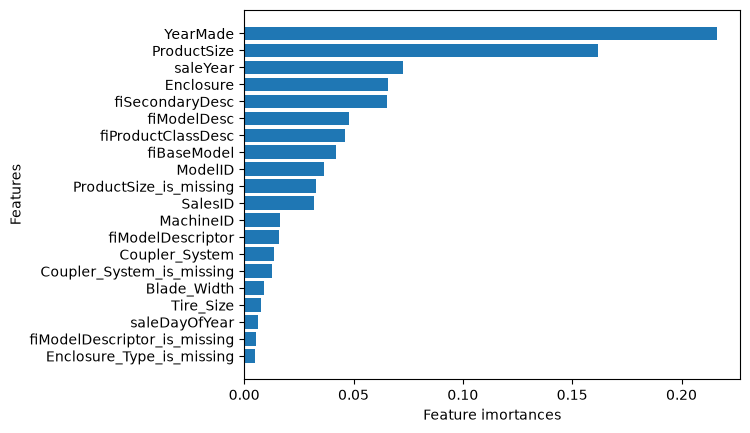

In [139]:
plot_features(X_train.columns, rs_model6.best_estimator_.feature_importances_)

#### **Final challenge**: ***What other ML models could u try on our dataset?Hint: https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html check out the regression section of this map OR try to look at smth like CatBoost.ai or XGBoost.ai***

#### **Answer**: ***I will go theu this after the whole course(i.e when i fully start cretating models)***